# ANN Lab 1 — Classification on Iris & Wine Datasets

| Field | Detail |
|---|---|
| **Name** | Muhammad Taqui |
| **Enrollment No** | 01-136221-021 |
| **Class** | BS AI (6-A) |

## Aim

Introduction to basic Python functions for data pre-processing. Build and compare four classifiers:
1. Decision Tree
2. Random Forest
3. Naïve Bayes
4. K-Nearest Neighbour (KNN)

## Theory

Data pre-processing involves handling missing values, encoding categorical variables, and scaling features. The dataset is split into training and testing subsets to measure generalisation. Four classifiers from scikit-learn are trained and evaluated on accuracy, precision, recall, and F1 score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

## Part 1 — Iris Dataset

In [2]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

print("Shape:", df_iris.shape)
print("Missing values:\n", df_iris.isnull().sum())
df_iris.head()

Shape: (150, 5)
Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X_iris = df_iris.drop('target', axis=1)
y_iris = df_iris['target']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=0
)

In [4]:
iris_models = {
    'Decision Tree':  DecisionTreeClassifier(random_state=0),
    'Random Forest':  RandomForestClassifier(n_estimators=20, random_state=0),
    'Naïve Bayes':    GaussianNB(),
    'KNN':            KNeighborsClassifier()
}

iris_results = {}
for name, model in iris_models.items():
    model.fit(X_train_i, y_train_i)
    preds = model.predict(X_test_i)
    acc = accuracy_score(y_test_i, preds)
    iris_results[name] = acc
    print(f"{name}: {acc:.4f}")

Decision Tree: 1.0000
Random Forest: 0.9667
Naïve Bayes: 0.9667
KNN: 0.9667


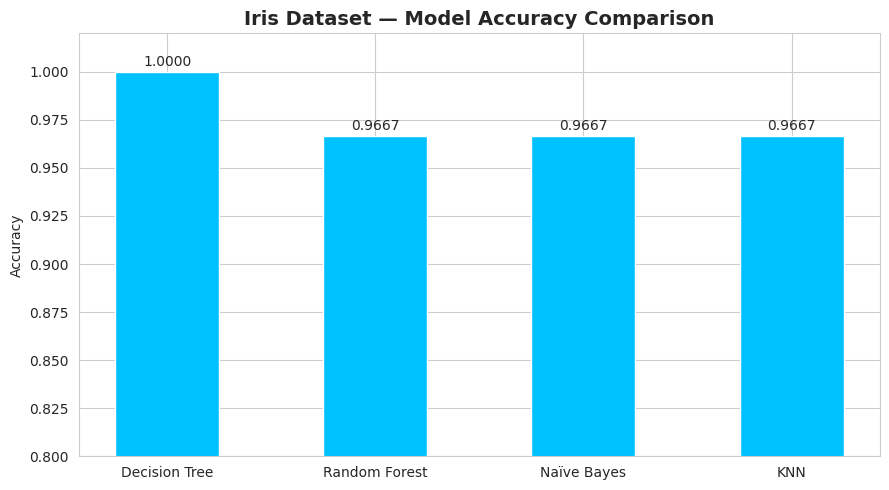

In [5]:
sns.set_style('whitegrid')
plt.figure(figsize=(9, 5))
bars = plt.bar(iris_results.keys(), iris_results.values(), color='#00C2FF', width=0.5)
plt.ylim(0.8, 1.02)
plt.title('Iris Dataset — Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
for bar, val in zip(bars, iris_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Part 2 — Wine Dataset

In [6]:
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target

print("Shape:", df_wine.shape)
print("Missing values:\n", df_wine.isnull().sum())
df_wine.head()

Shape: (178, 14)
Missing values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
X_wine = df_wine.drop('target', axis=1)
y_wine = df_wine['target']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=0
)

In [8]:
wine_models = {
    'Decision Tree':  DecisionTreeClassifier(random_state=0),
    'Random Forest':  RandomForestClassifier(n_estimators=50, max_features='sqrt', random_state=0),
    'Naïve Bayes':    GaussianNB(),
    'KNN':            KNeighborsClassifier()
}

wine_results = {}
for name, model in wine_models.items():
    model.fit(X_train_w, y_train_w)
    preds = model.predict(X_test_w)
    acc = accuracy_score(y_test_w, preds)
    wine_results[name] = acc
    print(f"{name}: {acc:.4f}")

Decision Tree: 0.9722
Random Forest: 0.9444
Naïve Bayes: 0.9167
KNN: 0.8056


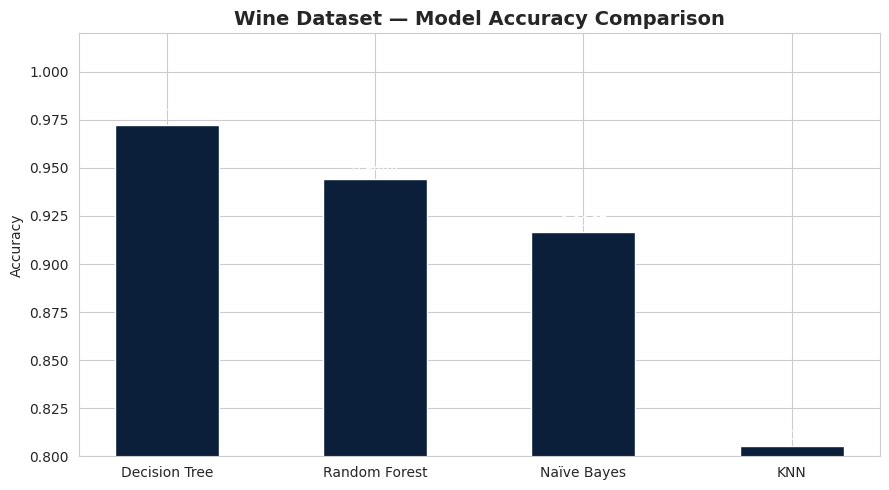

In [9]:
plt.figure(figsize=(9, 5))
bars = plt.bar(wine_results.keys(), wine_results.values(), color='#0B1F3B', width=0.5)
plt.ylim(0.8, 1.02)
plt.title('Wine Dataset — Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
for bar, val in zip(bars, wine_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=10, color='white')
plt.tight_layout()
plt.show()

## Conclusion

On both datasets Decision Tree and Random Forest achieve the highest accuracy. KNN underperforms without feature scaling — normalisation would likely close the gap. Naïve Bayes is competitive given its simplicity and speed.

In [10]:
# iTaqiZ - PK